<a href="https://colab.research.google.com/github/imgokulgk369-ship-it/Meditrack/blob/main/Data_preprocessing_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split


# Lab Exercise 1: Data pre-processing using Google colab
**Dataset: Titanic Dataset**

## Question 1: Load a Dataset and Display Basic Information


In [8]:
df = sns.load_dataset("titanic")

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Question 2: Display Number of Rows, Columns, Data Types and Missing Values

In [9]:
print("Number of Rows:", df.shape[0])

print("Number of Columns:", df.shape[1])

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Number of Rows: 891
Number of Columns: 15

Data Types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


## Question 3: Display First, Last and Random Records

In [10]:
print("First 5 Records:")
display(df.head())

print("Last 5 Records:")
display(df.tail())

print("Random 5 Records:")
display(df.sample(5))

First 5 Records:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Last 5 Records:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


Random 5 Records:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
398,0,2,male,23.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
593,0,3,female,NaN,0,2,7.7500,Q,Third,woman,False,NaN,Queenstown,no,False
581,1,1,female,39.0,1,1,110.8833,C,First,woman,False,C,Cherbourg,yes,False
705,0,2,male,39.0,0,0,26.0000,S,Second,man,True,NaN,Southampton,no,True
161,1,2,female,40.0,0,0,15.7500,S,Second,woman,False,NaN,Southampton,yes,True


## Question 4: Detect and Handle Missing Values

In [12]:
print("Missing Values Before:")
print(df.isnull().sum())

df['age'] = df['age'].fillna(df['age'].median())

df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

df['deck'] = df['deck'].astype(str)
df['deck'] = df['deck'].replace('nan', 'Unknown')

df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

print("\nMissing Values After:")
print(df.isnull().sum())

Missing Values Before:
survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Missing Values After:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


## Question 5: Identify and Remove Duplicate Records

In [13]:
print("Duplicate Records:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates After Removal:", df.duplicated().sum())

Duplicate Records: 110
Duplicates After Removal: 0


## Question 6: Detect Outliers Using IQR and Box Plot

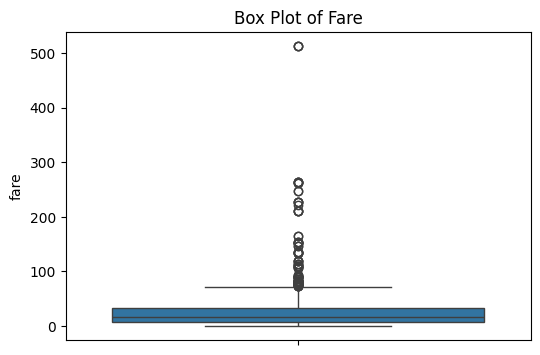

In [14]:
plt.figure(figsize=(6, 4))

sns.boxplot(y=df['fare'])

plt.title("Box Plot of Fare")

plt.show()

In [15]:
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['fare'] < lower) | (df['fare'] > upper)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 102


## Question 7: Handle Outliers Using Suitable Preprocessing Technique

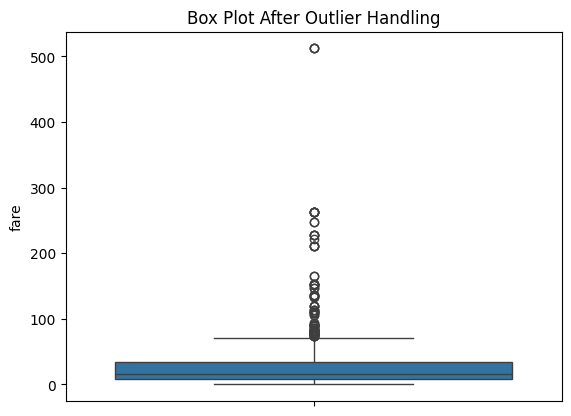

In [16]:
sns.boxplot(y=df['fare'])

plt.title("Box Plot After Outlier Handling")

plt.show()

## Question 9: Apply Feature Scaling Techniques

In [17]:
# Min-Max Normalization
minmax = MinMaxScaler()

df['age_normalized'] = minmax.fit_transform(df[['age']])

# Z-score Standardization
standard = StandardScaler()

df['fare_standardized'] = standard.fit_transform(df[['fare']])

df[['age', 'age_normalized', 'fare', 'fare_standardized']].head()

,age,age_normalized,fare,fare_standardized
0,22.0,0.271174,7.2500,-0.526784
1,38.0,0.472229,71.2833,0.699803
2,26.0,0.321438,7.9250,-0.513854
3,35.0,0.434531,53.1000,0.351494
4,35.0,0.434531,8.0500,-0.511460


## Question 10: Perform Feature Selection Using Correlation Analysis

In [18]:
numeric_data = df.select_dtypes(include='number')

correlation = numeric_data.corr()

print(correlation['survived'])

survived             1.000000
pclass              -0.330755
age                 -0.079430
sibsp               -0.038368
parch                0.068834
fare                 0.246585
age_normalized      -0.079430
fare_standardized    0.246585
Name: survived, dtype: float64


## Question 11: Generate Correlation Matrix and Visualize Using Heatmap

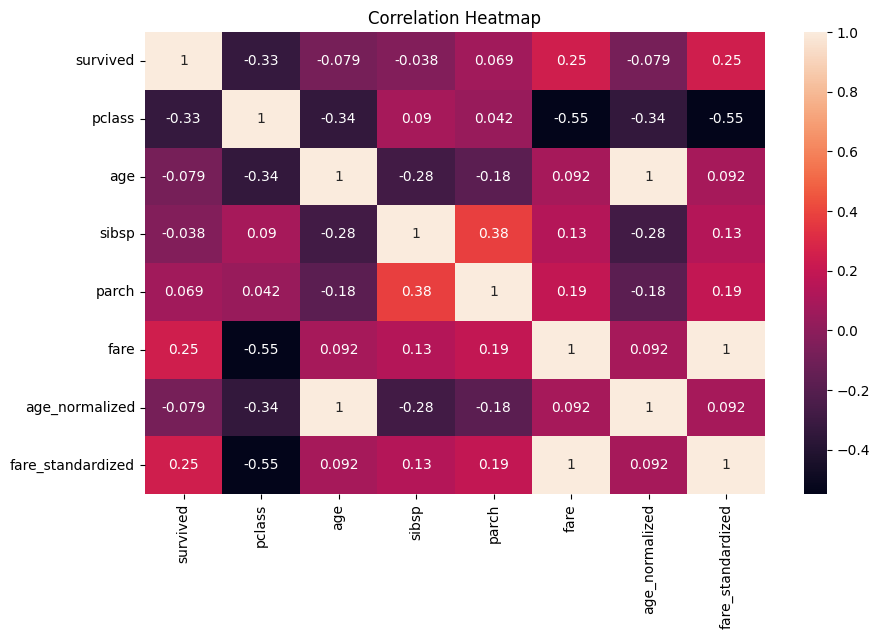

In [19]:
plt.figure(figsize=(10, 6))

sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")

plt.show()

## Question 13: Convert Data Types of Selected Columns

In [20]:
print("Before Conversion:")
print(df[['survived', 'age']].dtypes)

df['survived'] = df['survived'].astype(int)
df['age'] = df['age'].astype(int)

print("\nAfter Conversion:")
print(df[['survived', 'age']].dtypes)

Before Conversion:
survived      int64
age         float64
dtype: object

After Conversion:
survived    int64
age         int64
dtype: object


## Question 14: Handle Inconsistent and Noisy Data

In [21]:
df['sex'] = df['sex'].str.lower()

df['embark_town'] = df['embark_town'].str.strip()

print(df['sex'].unique())

print(df['embark_town'].unique())

['male' 'female']
['Southampton' 'Cherbourg' 'Queenstown']


## Question 15: Split Dataset into Training and Testing Sets

In [22]:
X = df[['pclass', 'age', 'fare']]

y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)

print("Testing Data:", X_test.shape)

Training Data: (624, 3)
Testing Data: (157, 3)


## Question 17: Visualize Numerical Features Before and After Preprocessing

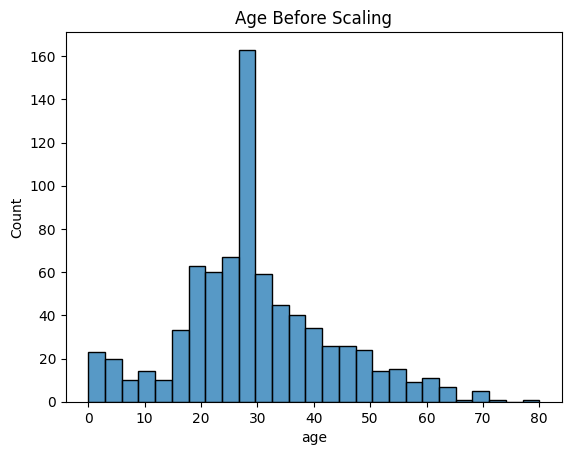

In [23]:
sns.histplot(df['age'])

plt.title("Age Before Scaling")

plt.show()

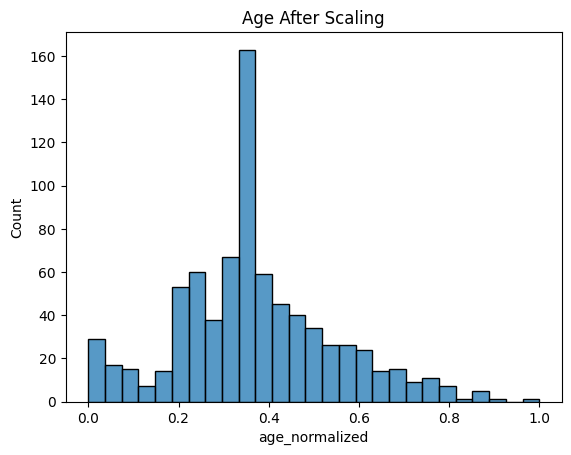

In [24]:
sns.histplot(df['age_normalized'])

plt.title("Age After Scaling")

plt.show()

## Question 18: Compare Dataset Before and After Preprocessing

In [25]:
comparison = {
    'Before Preprocessing': [
        'Missing values present',
        'Outliers present',
        'Data not scaled'
    ],
    'After Preprocessing': [
        'Missing values handled',
        'Outliers handled',
        'Data scaled'
    ]
}

pd.DataFrame(comparison)

,Before Preprocessing,After Preprocessing
0,Missing values present,Missing values handled
1,Outliers present,Outliers handled
2,Data not scaled,Data scaled


## Question 19: Save the Cleaned Dataset as a CSV File

In [26]:
df.to_csv("titanic_preprocessed.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully
